# TTC Subway Delay Analysis: Drivers and Short-Term Forecasting

## Business Problem

The Toronto Transit Commission (TTC) subway network experiences frequent service delays that affect rider experience, operating costs, and public confidence in the system. This project addresses two business questions for TTC operations planning: first, which operational and situational factors are most associated with delays, so that resources such as station security, staffing, and maintenance can be prioritized; and second, whether near-term delay volume can be forecast with reasonable accuracy, which would support proactive staffing and communication planning.

## Data Source

The dataset consists of subway delay records published by the City of Toronto Open Data Portal, covering 2018 through the most recent available data. Each record corresponds to a single reported delay event, with fields including date, time, station, delay cause code, line, delay duration in minutes, and the gap between trains in minutes. A separate reference table documents the meaning of each delay cause code.

## Approach

The analysis is organized in three parts. The first covers data acquisition, cleaning, and quality checks, ensuring the dataset is consistent and comparable across years. The second is exploratory and diagnostic: examining the volume and distribution of delays, and ranking delay causes with a Pareto analysis to identify which causes account for the majority of lost service time. The third builds two predictive models: a Random Forest classifier that estimates which situational features (line, time of day, day of week) are most predictive of a delay occurring, and a SARIMA time series model that forecasts the daily number of delay incidents.

## 1. Setup

Import the libraries used throughout the analysis: `pandas` and `requests` for data acquisition and manipulation, and `matplotlib` for visualization.

In [1]:
import pandas as pd
import requests
from io import BytesIO
import re
import matplotlib.pyplot as plt

## 2. Load Delay Code Reference Data

The City of Toronto publishes a `ttc-subway-delay-codes` reference table documenting the meaning of every delay cause code. This table is split into two lookups: `codes_df1` for subway line (SUB) codes and `codes_df2` for Scarborough Rapid Transit (SRT) codes. These lookups are used later to translate delay cause codes into readable descriptions.

In [2]:
import requests

# Toronto Open Data is stored in a CKAN instance. It's APIs are documented here:
# https://docs.ckan.org/en/latest/api/

# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
url = base_url + "/api/3/action/package_show"
params = { "id": "ttc-subway-delay-data"}
package = requests.get(url, params = params).json()

# To get resource data:
for idx, resource in enumerate(package["result"]["resources"]):

       # To get metadata for non datastore_active resources:
       if not resource["datastore_active"]:
           url = base_url + "/api/3/action/resource_show?id=" + resource["id"]
           resource_metadata = requests.get(url).json()
           print(resource_metadata)
           # From here, you can use the "url" attribute to download this file


{'help': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/help_show?name=resource_show', 'success': True, 'result': {'cache_last_updated': None, 'cache_url': None, 'created': '2019-07-23T18:12:29.977939', 'datastore_active': False, 'extract_job': 'Airflow: upload_remote_files', 'format': 'XLSX', 'hash': '', 'id': '3900e649-f31e-4b79-9f20-4731bbfd94f7', 'is_datastore_cache_file': False, 'is_preview': 'False', 'last_modified': '2022-04-06T18:51:05', 'metadata_modified': '2022-04-12T18:45:09.131087', 'mimetype': 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet', 'mimetype_inner': None, 'name': 'ttc-subway-delay-codes', 'package_id': '996cfe8d-fb35-40ce-b569-698d51fc683b', 'position': 0, 'resource_type': None, 'revision_id': 'c67fd8f7-cf16-41a7-b7f2-d508acaee8f1', 'size': 20206, 'state': 'active', 'url': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/996cfe8d-fb35-40ce-b569-698d51fc683b/resource/3900e649-f31e-4b79-9f20-4731bbfd94f7/download/ttc-subw

In [3]:
import requests
from io import BytesIO

# pick the specific resource you want, e.g. by name, rather than relying on the last loop iteration
target = next(
    r for r in package["result"]["resources"]
    if r["name"] == "ttc-subway-delay-codes"
)

resource_metadata = requests.get(base_url + "/api/3/action/resource_show?id=" + target["id"]).json()
file_url = resource_metadata["result"]["url"]

resp = requests.get(file_url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

print(resp.headers.get("Content-Type"))  # sanity check it's really an xlsx

df_codes = pd.read_excel(BytesIO(resp.content), skiprows=1, engine="openpyxl")


application/vnd.openxmlformats-officedocument.spreadsheetml.sheet


In [5]:
df_codes.head(5)

,Unnamed: 0,Unnamed: 1,SUB RMENU CODE,CODE DESCRIPTION,Unnamed: 4,Unnamed: 5,SRT RMENU CODE,CODE DESCRIPTION.1
0,NaN,1,EUAC,Air Conditioning,NaN,1.0,ERAC,Air Conditioning
1,NaN,2,EUAL,Alternating Current,NaN,2.0,ERBO,Body
2,NaN,3,EUATC,ATC RC&S Equipment,NaN,3.0,ERCD,Consequential Delay (2nd Delay Same Fault)
3,NaN,4,EUBK,Brakes,NaN,4.0,ERCO,Couplers
4,NaN,5,EUBO,Body,NaN,5.0,ERDB,Disc Brakes


In [6]:
codes_df1 = df_codes[['SUB RMENU CODE', 'CODE DESCRIPTION']].copy()
codes_df2 = df_codes[['SRT RMENU CODE', 'CODE DESCRIPTION']].copy()

In [10]:
print(codes_df1.head(5),end='\n')
print()
print(codes_df2.head(5), end='\n')


  SUB RMENU CODE     CODE DESCRIPTION
0           EUAC     Air Conditioning
1           EUAL  Alternating Current
2          EUATC   ATC RC&S Equipment
3           EUBK               Brakes
4           EUBO                 Body

  SRT RMENU CODE     CODE DESCRIPTION
0           ERAC     Air Conditioning
1           ERBO  Alternating Current
2           ERCD   ATC RC&S Equipment
3           ERCO               Brakes
4           ERDB                 Body


### Findings

The reference table confirms that subway (SUB) and Scarborough RT (SRT) delay codes use separate, non-overlapping coding systems, even where the underlying cause is conceptually the same, for example both systems define distinct codes for "Air Conditioning". Both lookup tables are retained for use later when translating cause codes into readable descriptions.

## 3. Initial Exploration: 2018 Data

Before building the full multi-year pipeline, a single year (2018) is loaded first to understand the raw structure of the delay data, including its columns and formatting, before scaling the process to all available years.

In [11]:
import requests
from io import BytesIO

# pick the specific resource you want, e.g. by name, rather than relying on the last loop iteration
target = next(
    r for r in package["result"]["resources"]
    if r["name"] == "ttc-subway-delay-data-2018"
)

resource_metadata = requests.get(base_url + "/api/3/action/resource_show?id=" + target["id"]).json()
file_url = resource_metadata["result"]["url"]

resp = requests.get(file_url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

print(resp.headers.get("Content-Type"))  # sanity check it's really an xlsx

df_2018 = pd.read_excel(BytesIO(resp.content),  engine="openpyxl") #skiprows=1,


application/vnd.openxmlformats-officedocument.spreadsheetml.sheet


In [12]:
df_2018.head(5)

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
0,2018-01-01,00:29,Monday,SHEPPARD WEST STATION,MUATC,10,15,N,YU,5986
1,2018-01-01,01:07,Monday,DUNDAS STATION,MUNCA,0,0,NaN,YU,0
2,2018-01-01,01:22,Monday,MUSEUM STATION,MUSC,0,0,N,YU,5751
3,2018-01-01,01:28,Monday,BAY LOWER,EUOE,0,0,NaN,BD,5222
4,2018-01-01,01:39,Monday,MUSEUM STATION,MUO,6,11,S,YU,5781


### Findings

The 2018 file confirms the core schema used across years: `Date`, `Time`, `Day`, `Station`, `Code`, `Min Delay`, `Min Gap`, `Bound`, `Line`, and `Vehicle`. This structure is consistent enough across years to support a straightforward concatenation in the next step.

## 4. ETL: Consolidating All Available Years (2018-2025)

Each year's delay data is published as a separate resource, in XLSX format for 2018-2024 and CSV from 2025 onward. This step loops through every year, retrieves the corresponding file, and concatenates the results into a single combined dataframe, `df_all`, which serves as the base for all subsequent analysis.

In [13]:
import requests
from io import BytesIO

years = range(2018, 2025)  # 2018 a 2024 (xlsx)
all_dfs = []

for year in years:
    resource_name = f"ttc-subway-delay-data-{year}"
    
    target = next(
        (r for r in package["result"]["resources"] if r["name"] == resource_name),
        None
    )
    
    if target is None:
        print(f"No se encontró recurso para {year}, revisar nombre")
        continue
    
    resource_metadata = requests.get(
        base_url + "/api/3/action/resource_show?id=" + target["id"]
    ).json()
    file_url = resource_metadata["result"]["url"]
    
    resp = requests.get(file_url, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()
    
    df_year = pd.read_excel(BytesIO(resp.content), engine="openpyxl")
    df_year["Year"] = year
    
    all_dfs.append(df_year)
    print(f"{year}: {df_year.shape[0]} filas cargadas")

# --- Caso especial: datos desde 2025 en adelante, vienen como CSV ---
target_2025 = next(
    (r for r in package["result"]["resources"] if r["name"] == "TTC Subway Delay Data since 2025"),
    None
)

if target_2025 is not None:
    resource_metadata = requests.get(
        base_url + "/api/3/action/resource_show?id=" + target_2025["id"]
    ).json()
    file_url = resource_metadata["result"]["url"]
    
    resp = requests.get(file_url, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()
    
    df_2025 = pd.read_csv(BytesIO(resp.content))
    df_2025["Year"] = 2025  # o extraer el año real de la columna Date si abarca varios años
    
    all_dfs.append(df_2025)
    print(f"2025+: {df_2025.shape[0]} filas cargadas")
else:
    print("No se encontró el recurso CSV de 2025")

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.shape

2018: 1873 filas cargadas
2019: 1871 filas cargadas
2020: 1339 filas cargadas
2021: 1216 filas cargadas
2022: 19895 filas cargadas
2023: 22949 filas cargadas
2024: 26467 filas cargadas
2025+: 40656 filas cargadas


(116266, 12)

## 5. Data Quality and Homogeneity Checks

Before any analysis, it is important to confirm that data collected across different years and source files can be safely compared. This section checks three things: whether the most recent resource, nominally "since 2025", contains unexpected future-dated records; whether row counts and the proportion of zero-minute delay entries are stable from year to year; and what the official data dictionary documents for each field.

In [14]:
df_all['Date'] = pd.to_datetime(df_all['Date'])
df_all[df_all['Date'].dt.year == 2026]

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,Year,_id
101347,2026-01-01,02:09,Thursday,SHEPPARD STATION,SUAP,0,0,NaN,YU,0,2025,25738.0
101348,2026-01-01,02:28,Thursday,KIPLING STATION,MUIS,0,0,E,BD,5179,2025,25739.0
101349,2026-01-01,03:19,Thursday,SHEPPARD WEST STATION,MUIS,0,0,NaN,YU,0,2025,25740.0
101350,2026-01-01,03:44,Thursday,VMC STATION,MUIS,0,0,NaN,YU,0,2025,25741.0
101351,2026-01-01,03:53,Thursday,KIPLING STATION,MUIS,0,0,NaN,BD,0,2025,25742.0
...,...,...,...,...,...,...,...,...,...,...,...,...
116261,2026-06-30,01:37,Tuesday,KENNEDY BD STATION,SUDP,0,0,W,BD,0,2025,40652.0
116262,2026-06-30,17:57,Tuesday,SHEPPARD-YONGE STATION,TUSC,0,0,W,SHP,6191,2025,40653.0
116263,2026-06-30,18:53,Tuesday,DON MILLS STATION,PUMEL,0,0,NaN,SHP,0,2025,40654.0
116264,2026-06-30,21:04,Tuesday,SHEPPARD-YONGE STATION,EUO,0,0,E,SHP,6161,2025,40655.0


In [15]:
for d in all_dfs:
    yr = d['Year'].iloc[0]
    zero_pct = (d['Min Delay'] == 0).mean() * 100
    print(yr, '| rows:', d.shape[0], '| columns:', d.columns.tolist(), '| %zero delay:', round(zero_pct,1))

2018 | rows: 1873 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Line', 'Vehicle', 'Year'] | %zero delay: 62.3
2019 | rows: 1871 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Line', 'Vehicle', 'Year'] | %zero delay: 64.1
2020 | rows: 1339 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Line', 'Vehicle', 'Year'] | %zero delay: 59.1
2021 | rows: 1216 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Line', 'Vehicle', 'Year'] | %zero delay: 53.9
2022 | rows: 19895 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Line', 'Vehicle', 'Year'] | %zero delay: 54.9
2023 | rows: 22949 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Line', 'Vehicle', 'Year'] | %zero delay: 64.1
2024 | rows: 26467 | columns: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 

In [17]:
target_readme = next(r for r in package["result"]["resources"] if r["name"] == "ttc-subway-delay-data-readme")
resource_metadata = requests.get(base_url + "/api/3/action/resource_show?id=" + target_readme["id"]).json()
file_url = resource_metadata["result"]["url"]
resp = requests.get(file_url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()
xls = pd.ExcelFile(BytesIO(resp.content), engine="openpyxl")
print(xls.sheet_names)
for s in xls.sheet_names:
    print('---', s, '---')
    print(xls.parse(s).head(20))

['Meta Data']
--- Meta Data ---
  Field Name                                Description              Example
0       Date                          Date (YYYY/MM/DD)  2016-12-31 00:00:00
1       Time                           Time (24h clock)             01:59:00
2        Day                Name of the day of the week             Saturday
3    Station                    TTC subway station name     Rosedale Station
4       Code                             TTC delay code                 MUIS
5  Min Delay       Delay (in minutes) to subway service                    5
6    Min Gap    Time length (in minutes) between trains                    9
7      Bound   Direction of train dependant on the line                    N
8       Line  TTC subway line i.e. YU, BD, SHP, and SRT                   YU
9    Vehicle                           TTC train number                 5961


### Findings

The "since 2025" resource contains records dated into 2026, indicating that it is updated on a rolling basis rather than being a fixed annual file; these records must be excluded when the analysis is restricted to complete calendar years. Row counts increase sharply from 2018-2021, roughly 1,200 to 1,900 records per year, to 2022 onward, roughly 19,000 to 27,000 records per year, which points to a change in how delays were logged or reported rather than an actual multi-fold increase in real-world delay events; comparing raw counts across the full 2018-2025 span would therefore be misleading. The share of records with zero recorded delay minutes stays broadly stable, between roughly 54 and 65 percent across years, meaning many logged entries are routine operational records rather than actual service disruptions. Based on these findings, the analysis that follows uses only the 2022-2025 period, where reporting volume is consistent.

## 6. Line Column Exploration (Draft, Not Yet Applied)

The `Line` column contains many inconsistent variants of the same line, for example `YU/BD`, `YUS`, and even bus route numbers entered in error. This section inspects the raw values and drafts a standardization function, `standardize_line()`. The function is not applied at this point in the notebook; it is used later, in the feature engineering step, once the analysis has been scoped to the comparable 2022-2025 period.

In [18]:
df_all['Line'].value_counts()

Line
YU                        60123
BD                        47618
SHP                        4246
SRT                        2145
YU/BD                      1576
YUS/BD                       60
YU / BD                      38
YU/ BD                       27
YUS                          27
BD/YU                        21
YU & BD                      15
YU/BD/SHP                     9
YU/BD LINES                   6
BD/YUS                        5
999                           4
YUS / BD                      2
B/D                           2
LINE 1                        2
EC                            2
YU/BD LINE                    2
BD LINE 2                     2
506 CARLTON                   2
95 YORK MILLS                 1
508 LAKESHORE                 1
116 MORNINGSIDE               1
YUS/ BD/ SHP                  1
YU -BD LINES                  1
62 MORTIMER                   1
LINE 2 - BLOOR DANFORT        1
YUS/BD/SHP                    1
29 DUFFERIN                   1
20 

In [19]:
import re

def standardize_line(val):
    if pd.isna(val):
        return val
    v = str(val).upper().strip()

    # Junk / non-line values -> Unknown
    junk_patterns = ['TRACK LEVEL', 'STN', '999']
    if any(p in v for p in junk_patterns) or re.match(r'^\d{2,3}\s', v):
        return 'UNKNOWN'  # catches bus route numbers like "506 CARLTON"

    # Normalize separators so combos are consistent
    v_norm = re.sub(r'[\s\-&/]+', '/', v)  # turn -, &, spaces, slashes into a single "/"
    v_norm = v_norm.replace('LINES', '').replace('LINE', '').strip('/')

    # Map old naming (YUS) to current (YU)
    v_norm = v_norm.replace('YUS', 'YU')

    # Known single-line names spelled out
    if 'BLOOR' in v_norm or v_norm in ('BD', 'B/D'):
        return 'BD'
    if v_norm in ('SHEP', 'SHP'):
        return 'SHP'
    if v_norm == 'EC' or 'ECLRT' in v_norm:
        return 'EC'
    if v_norm == 'FWLRT':
        return 'FWLRT'
    if v_norm == 'SRT':
        return 'SRT'
    if v_norm == 'YU':
        return 'YU'

    # Multi-line combos -> sort parts alphabetically so "YU/BD" and "BD/YU" match
    parts = sorted(set(p for p in v_norm.split('/') if p))
    if parts:
        return '/'.join(parts)

    return 'UNKNOWN'

df_all['Line_clean'] = df_all['Line'].apply(standardize_line)
df_all['Line_clean'].value_counts()

Line_clean
YU                        60150
BD                        47626
SHP                        4247
SRT                        2145
BD/YU                      1758
UNKNOWN                      23
BD/SHP/YU                    11
EC                            3
2/BD                          2
1                             2
BD/Y                          1
AND/BD/YU                     1
2/SHUTTLE                     1
AND/BL/ONGE/UNIVERSITY        1
Name: count, dtype: int64

### Findings

The raw `Line` field contains more than two dozen distinct string variants for what are effectively four or five actual subway lines, including inconsistent separators (`YU/BD`, `YU / BD`, `YU & BD`), a legacy naming convention (`YUS` for what is now `YU`), and data entry errors such as bus route numbers (`506 CARLTON`, `95 YORK MILLS`) and a placeholder value (`999`). The `standardize_line()` function drafted here resolves these into a small set of consistent line labels, a necessary precondition for using `Line` as a reliable predictive feature.

## 7. Filter to Comparable Period (2022-2025)

Based on the data quality checks above, 2018-2021 is excluded due to substantially lower reporting volume, and records are restricted to 2022 through 2025. Line 3 (Scarborough RT) also closed permanently in 2023, which is an additional reason to avoid mixing pre-2022 and post-2022 periods. The real calendar year is derived directly from the `Date` field rather than relying on the source file's hardcoded `Year` column, which is unreliable for the reasons identified above.

In [20]:
df_all['Date'] = pd.to_datetime(df_all['Date'])
df_all['RealYear'] = df_all['Date'].dt.year

df_recent = df_all[(df_all['RealYear'] >= 2022) & (df_all['RealYear'] <= 2025)].copy()
df_recent['RealYear'].value_counts().sort_index()

RealYear
2022    19895
2023    22949
2024    26467
2025    25737
Name: count, dtype: int64

### Findings

After deriving the year from `Date` and filtering to 2022-2025, the working dataset (`df_recent`) contains 19,895 records in 2022, 22,949 in 2023, 26,467 in 2024, and 25,737 in 2025, for a combined total of roughly 95,000 records. Volume is broadly stable and slightly increasing year over year, confirming this is a reasonable and comparable analysis window.

## 8. Data Exploration (2022-2025)

With a clean and comparable dataset in place, this section examines the overall shape of the data: how delay minutes are distributed, how records are distributed across subway lines, and how they vary by day of week.

### Summary Statistics

In [21]:
df_recent[['Min Delay', 'Min Gap']].describe()

,Min Delay,Min Gap
count,95048.000000,95048.000000
mean,3.012446,4.374327
std,10.622295,11.394889
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,4.000000,8.000000
max,900.000000,906.000000


### Findings

Across all 95,048 records in `df_recent`, the median delay is 0 minutes and the mean is approximately 3.0 minutes, confirming that a large share of logged records represent routine operational entries rather than actual service disruptions, consistent with the zero-delay percentages observed earlier. The maximum recorded delay is 900 minutes, or 15 hours, indicating the presence of extreme outlier events, most likely major incidents rather than routine service variation. `Min Gap`, which measures the gap between trains, follows a similar pattern with a slightly higher mean, as expected since a delay to one train increases the gap experienced by the following train.

### Distribution of Delay Minutes (Delayed Records Only)

Restricting to records with a delay greater than zero minutes isolates the events that represent genuine service disruptions, and shows how severe a typical delay is once one actually occurs.

In [22]:
delay_only = df_recent[df_recent['Min Delay'] > 0]['Min Delay']
delay_only.describe()

count    35701.000000
mean         8.020139
std         16.131996
min          2.000000
25%          3.000000
50%          5.000000
75%          8.000000
max        900.000000
Name: Min Delay, dtype: float64

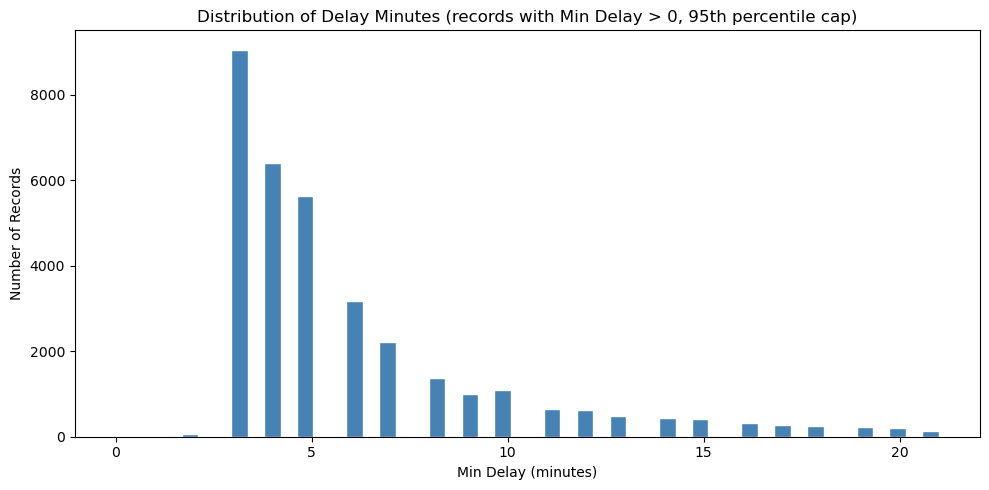

In [23]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(delay_only, bins=50, range=(0, delay_only.quantile(0.95)), color='steelblue', edgecolor='white')
ax.set_xlabel('Min Delay (minutes)')
ax.set_ylabel('Number of Records')
ax.set_title('Distribution of Delay Minutes (records with Min Delay > 0, 95th percentile cap)')
plt.tight_layout()
plt.show()

### Findings

Among the 35,701 genuine delay events, the median delay is 5 minutes and the mean is roughly 8 minutes, while the 75th percentile sits at 8 minutes, indicating that most delays are short and operationally minor. However, the maximum of 900 minutes and a standard deviation larger than the mean show a heavy right tail: a small number of severe incidents disproportionately affect total lost service time, a pattern confirmed later in the Pareto analysis.

### Records by Line

Delay records are broken down by subway line to identify which lines experience the highest volume of reported incidents.

In [24]:
df_recent['Line'].value_counts()

Line
YU                        49440
BD                        38422
SHP                        3538
SRT                        1931
YU/BD                      1327
YUS/BD                       32
YU / BD                      30
YU/ BD                       22
BD/YU                        17
YUS                          16
YU & BD                      15
YU/BD LINES                   6
BD/YUS                        3
EC                            2
LINE 1                        2
BD LINE 2                     2
YUS / BD                      2
YU/BD LINE                    2
YU/BD/SHP                     2
YUS/ BD/ SHP                  1
116 MORNINGSIDE               1
508 LAKESHORE                 1
95 YORK MILLS                 1
62 MORTIMER                   1
LINE 2 - BLOOR DANFORT        1
YUS/ BD                       1
20 CLIFFSIDE                  1
YU -BD LINES                  1
BD / YU                       1
BD/ YU                        1
BD/ YUS                       1
77 

### Findings

The Yonge-University line (YU) accounts for the largest share of delay records, followed by the Bloor-Danforth line (BD), together representing the majority of all logged incidents; this is expected given these are the two busiest and longest lines in the network. Line labels are highly inconsistent in the raw data, with dozens of variant spellings and combined-line entries, for example `YU/BD` and `YUS/BD`, reinforcing the need for the standardization step applied later in feature engineering.

### Records by Day of Week

Delay records are aggregated by day of week to check whether incident volume varies with the weekly commuting cycle.

In [25]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df_recent['Day'].value_counts().reindex(day_order)
day_counts

Day
Monday       14115
Tuesday      14415
Wednesday    14608
Thursday     14389
Friday       14310
Saturday     12368
Sunday       10843
Name: count, dtype: int64

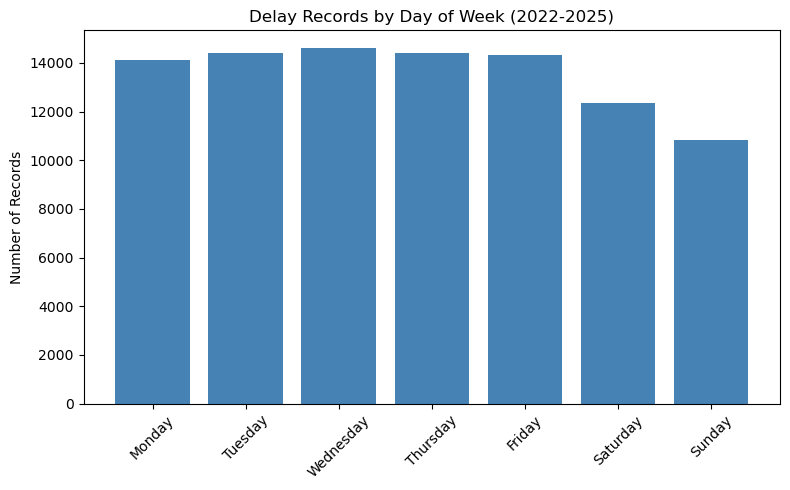

In [26]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(day_counts.index, day_counts.values, color='steelblue')
ax.set_ylabel('Number of Records')
ax.set_title('Delay Records by Day of Week (2022-2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings

Delay record counts are highest on weekdays, ranging from roughly 14,100 to 14,600 records, and noticeably lower on weekends, with about 12,400 records on Saturday and 10,800 on Sunday. This is consistent with weekday ridership being substantially higher than weekend ridership, and suggests that day of week, and by extension weekday commuting demand, is a relevant factor to include in a predictive model of delays.

## 9. Pareto Analysis of Delay Causes

Delay causes are ranked by total delay minutes contributed, rather than by frequency of occurrence alone, since a cause that occurs less often but produces much longer delays may matter more from an operations standpoint than a frequent but minor cause.

### Aggregation

Total delay minutes are summed by delay cause code, sorted in descending order, and the cumulative percentage of total delay time is calculated to identify the smallest set of causes responsible for the largest share of lost service time.

In [27]:
pareto = df_recent.groupby('Code')['Min Delay'].sum().sort_values(ascending=False).reset_index()
pareto.columns = ['Code', 'TotalDelayMinutes']
pareto['CumPct'] = pareto['TotalDelayMinutes'].cumsum() / pareto['TotalDelayMinutes'].sum() * 100

top20 = pareto.head(20)
top20

,Code,TotalDelayMinutes,CumPct
0,SUDP,31667,11.059732
1,SUUT,21044,18.409371
2,SUO,18077,24.722782
3,PUOPO,15324,30.074705
4,MUIR,14229,35.044198
5,MUI,13946,39.914853
6,MUPAA,11704,44.002487
7,MUPR1,11323,47.957056
8,MUPLB,7708,50.649083
9,SUAP,7227,53.173120


### Findings

Three cause codes alone account for close to a quarter of all delay minutes across 2022-2025: `SUDP` (11.1 percent of total delay minutes), `SUUT` (a further 7.3 percent, 18.4 percent cumulative), and `SUO` (a further 6.3 percent, 24.7 percent cumulative). Reaching 80 percent of total delay minutes requires the top 20 cause codes, indicating that while a handful of causes are dominant, delay time is still spread across a long tail of secondary causes rather than concentrated in just two or three.

### Visualization

The Pareto chart below combines total delay minutes per cause, shown as bars, with the cumulative percentage of total delay time, shown as a line, making it easy to see how quickly the cumulative curve approaches the 80 percent threshold.

/var/folders/wk/419k5hfx3ss_5jtrcdzf33_w0000gn/T/ipykernel_98574/1086003142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top20['Code'], rotation=90)


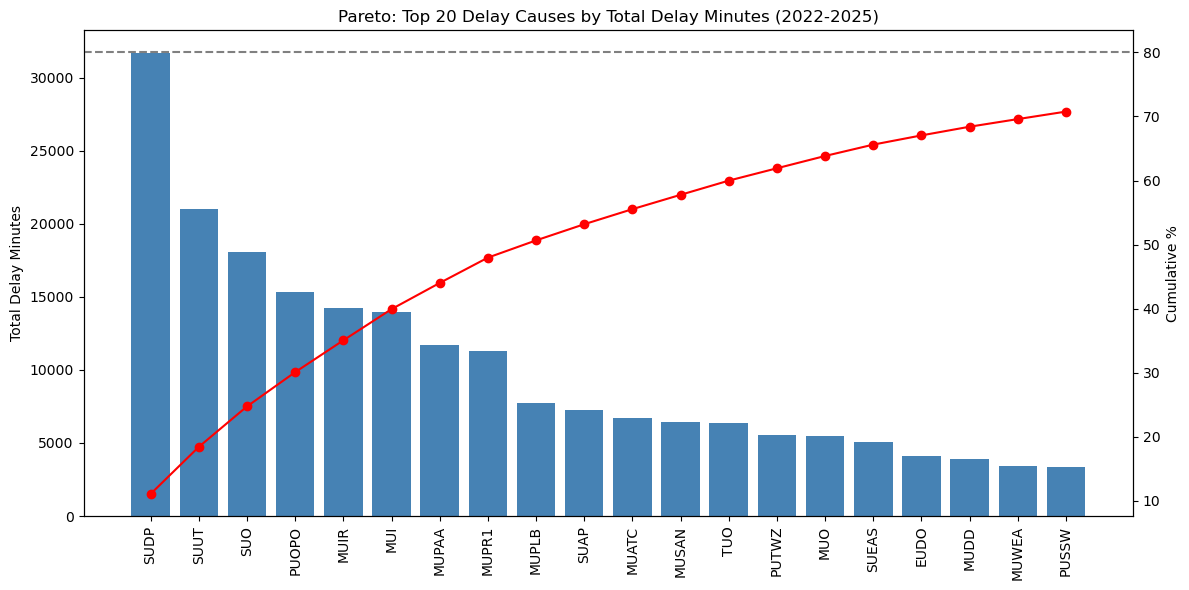

In [28]:
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(top20['Code'], top20['TotalDelayMinutes'], color='steelblue')
ax1.set_ylabel('Total Delay Minutes')
ax1.set_xticklabels(top20['Code'], rotation=90)

ax2 = ax1.twinx()
ax2.plot(top20['Code'], top20['CumPct'], color='red', marker='o')
ax2.set_ylabel('Cumulative %')
ax2.axhline(80, color='gray', linestyle='--')

plt.title('Pareto: Top 20 Delay Causes by Total Delay Minutes (2022-2025)')
plt.tight_layout()
plt.show()

### Code Definitions: Top 3 Causes by Total Delay Minutes

The three leading cause codes are decoded using the reference lookup table to understand what they represent operationally.

In [29]:
codes_df1[codes_df1['SUB RMENU CODE'].isin(['SUDP','SUUT','SUO'])]

,SUB RMENU CODE,CODE DESCRIPTION
104,SUDP,Disorderly Patron
107,SUO,Passenger Other
112,SUUT,Unauthorized at Track Level


### Findings

The three largest contributors to total delay time are not mechanical or equipment failures, but passenger and security related incidents: `SUDP` (Disorderly Patron), `SUUT` (Unauthorized at Track Level), and `SUO` (Passenger Other). This is a significant business insight: investment in station security, platform monitoring, and passenger communication may have a greater impact on reducing total delay minutes than investment in vehicle or signal maintenance alone, since these three passenger-related causes already account for close to a quarter of all lost service time.

## 10. Feature Engineering

To model whether a delay is likely to occur, three explanatory features are constructed: `Line_clean`, a standardized version of the `Line` column using the `standardize_line()` function drafted earlier; `TimeOfDay`, a bucketed version of the delay time (AM rush, midday, PM rush, evening, overnight); and `Day`, the day of week. The target variable, `IsDelayed`, flags whether a given record corresponds to an actual delay (`Min Delay` greater than zero). An external weather data source is identified as a natural extension for future work, since weather is a plausible driver of transit delays but is not present in the current dataset.

In [30]:
# Apply the existing standardize_line() draft for a clean route feature
df_recent['Line_clean'] = df_recent['Line'].apply(standardize_line)

# Time of day bucket, parsed from the raw 'Time' column (HH:MM)
df_recent['Hour'] = pd.to_datetime(df_recent['Time'], format='%H:%M', errors='coerce').dt.hour

def time_bucket(h):
    if pd.isna(h): return 'Unknown'
    if 5 <= h < 10: return 'AM_Rush'
    if 10 <= h < 15: return 'Midday'
    if 15 <= h < 19: return 'PM_Rush'
    if 19 <= h < 23: return 'Evening'
    return 'Overnight'

df_recent['TimeOfDay'] = df_recent['Hour'].apply(time_bucket)

# Target: did a delay actually occur on this logged record?
df_recent['IsDelayed'] = (df_recent['Min Delay'] > 0).astype(int)

# --- Weather join placeholder ---
# No weather column exists in the current data. You'll need an external daily
# weather source for Toronto (e.g. Environment Canada historical data, or the
# Open-Meteo historical API) joined on 'Date'. Example shape once you have it:
# weather_df columns: ['Date', 'TempC', 'PrecipMM', 'SnowCM', 'WindKmh']
# df_recent = df_recent.merge(weather_df, on='Date', how='left')

### Random Forest Feature Importance

A Random Forest classifier is trained to predict `IsDelayed` using the three engineered categorical features (`Line_clean`, `TimeOfDay`, `Day`), one-hot encoded. The model's feature importances indicate which categories are most predictive of a delay occurring, and the held-out test accuracy provides a baseline measure of how well these situational factors alone can predict delays.

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

features = ['Line_clean', 'TimeOfDay', 'Day']  # add weather columns here once joined
X = df_recent[features]
y = df_recent['IsDelayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), features)
])

pipe = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)
print('Test accuracy:', pipe.score(X_test, y_test))

# Extract feature importances mapped back to readable names
importances = pipe.named_steps['rf'].feature_importances_
feature_names = pipe.named_steps['prep'].get_feature_names_out()

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False)

importance_df.head(20)

Test accuracy: 0.628563913729616


,feature,importance
17,cat__TimeOfDay_Overnight,0.223153
7,cat__Line_clean_BD/YU,0.157342
12,cat__Line_clean_YU,0.126395
14,cat__TimeOfDay_AM_Rush,0.113949
4,cat__Line_clean_BD,0.080167
10,cat__Line_clean_SRT,0.054270
15,cat__TimeOfDay_Evening,0.052189
18,cat__TimeOfDay_PM_Rush,0.031956
9,cat__Line_clean_SHP,0.030480
16,cat__TimeOfDay_Midday,0.026866


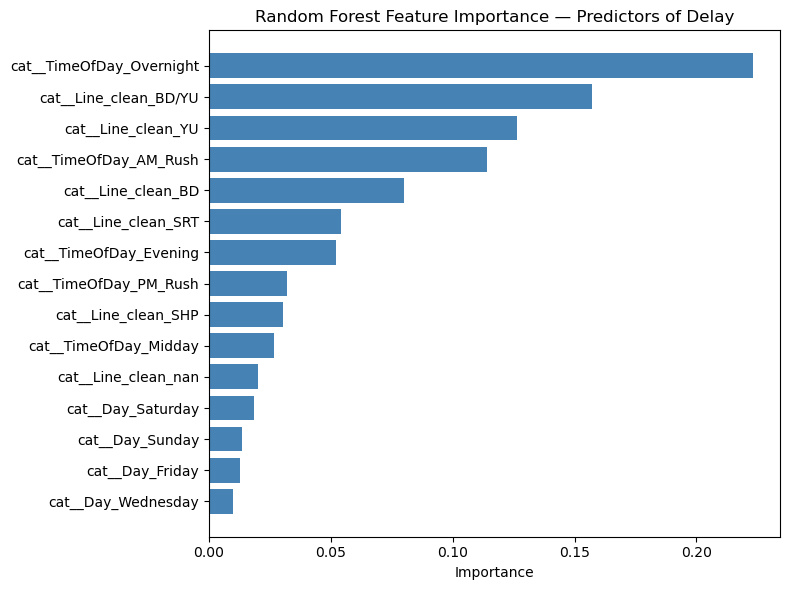

In [32]:
fig, ax = plt.subplots(figsize=(8,6))
top_imp = importance_df.head(15)
ax.barh(top_imp['feature'][::-1], top_imp['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance — Predictors of Delay')
plt.tight_layout()
plt.show()

### Findings

The model reaches a test accuracy of approximately 62.9 percent, only modestly better than a naive baseline given that 54 to 65 percent of records already carry zero delay minutes in a given year, based on the earlier data quality checks. This indicates that line, time of day, and day of week alone provide limited predictive power for whether a specific record will be a delay. Among the features used, the overnight time bucket, the combined BD/YU line grouping, the YU line individually, and the AM rush period contribute the most importance to the model. Day of week contributes comparatively little, suggesting that when and where a train is running matters more than which specific weekday it is. These results point directly to the feature gap noted above: without an external variable such as weather, mechanical condition, or real-time operational load, a classification model built only on schedule-related categories has a limited ceiling on accuracy.

## 11. SARIMA Analysis: Forecasting Daily Delay Volume

While the Random Forest model addresses which situational factors are associated with individual delay records, this section addresses the second business question directly: can the daily volume of delay incidents be forecast with reasonable accuracy. A SARIMA (Seasonal AutoRegressive Integrated Moving Average) model is used to forecast the daily count of delay incidents, a more operationally useful unit for staffing and planning purposes than delay minutes, since the latter is skewed by the rare extreme-duration events identified earlier.

### Exploratory Time Series Analysis

Before fitting a forecasting model, the daily incident count series is inspected for trend, seasonality, and stationarity. This includes visual inspection of the daily series, a seasonal decomposition assuming weekly seasonality, an Augmented Dickey-Fuller (ADF) stationarity test, and autocorrelation (ACF) and partial autocorrelation (PACF) plots used to identify candidate SARIMA orders.

2022-01-01 00:00:00 2025-12-31 00:00:00
1461 unique days


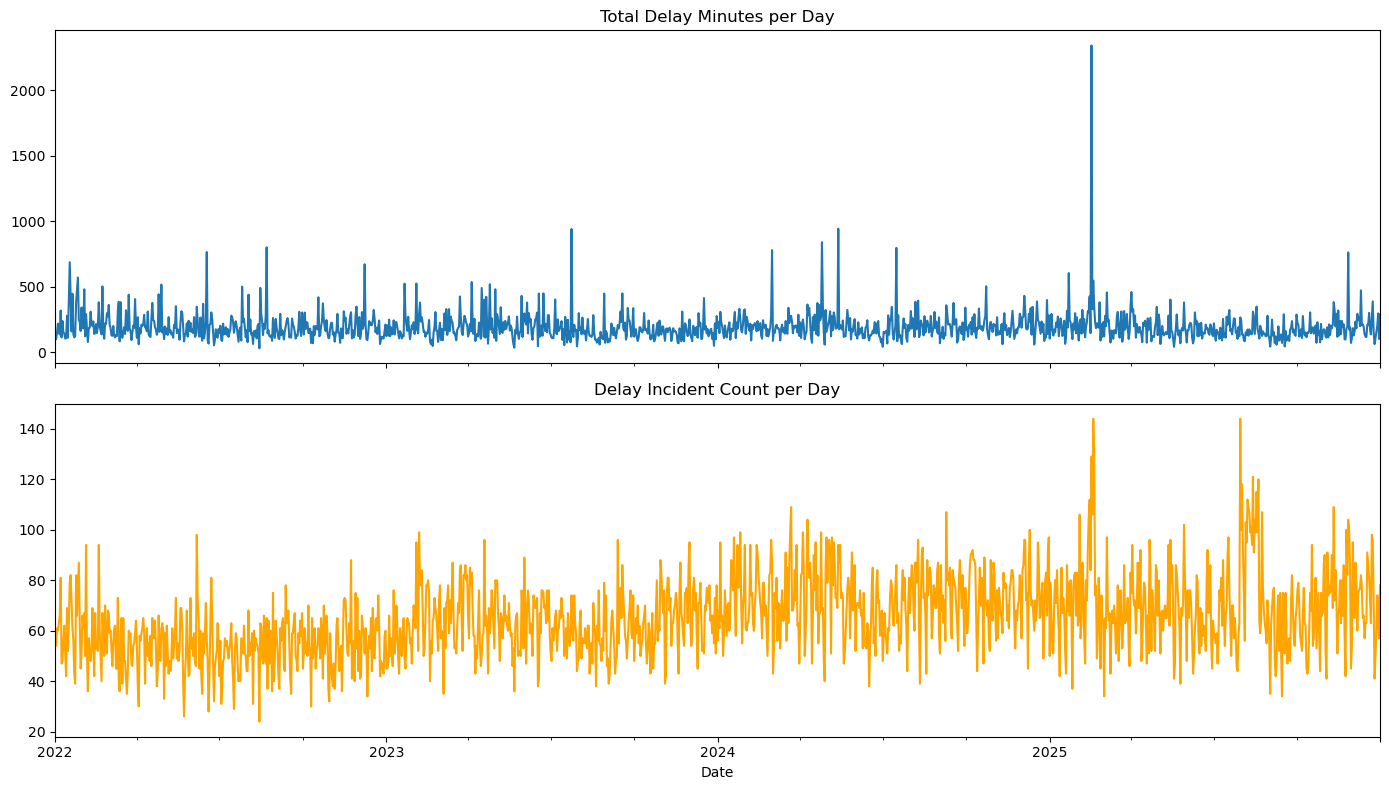

In [33]:
# 1. Check date range and basic shape
print(df_recent['Date'].min(), df_recent['Date'].max())
print(df_recent['Date'].nunique(), "unique days")

# 2. Build a daily time series: total delay minutes per day
daily = df_recent.groupby('Date')['Min Delay'].sum().asfreq('D').fillna(0)
daily = daily.rename('total_delay_min')

# 3. Also build daily count of incidents (compare later)
daily_count = df_recent.groupby('Date').size().asfreq('D').fillna(0)
daily_count = daily_count.rename('delay_count')

# 4. Quick plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
daily.plot(ax=axes[0], title='Total Delay Minutes per Day')
daily_count.plot(ax=axes[1], title='Delay Incident Count per Day', color='orange')
plt.tight_layout()
plt.show()

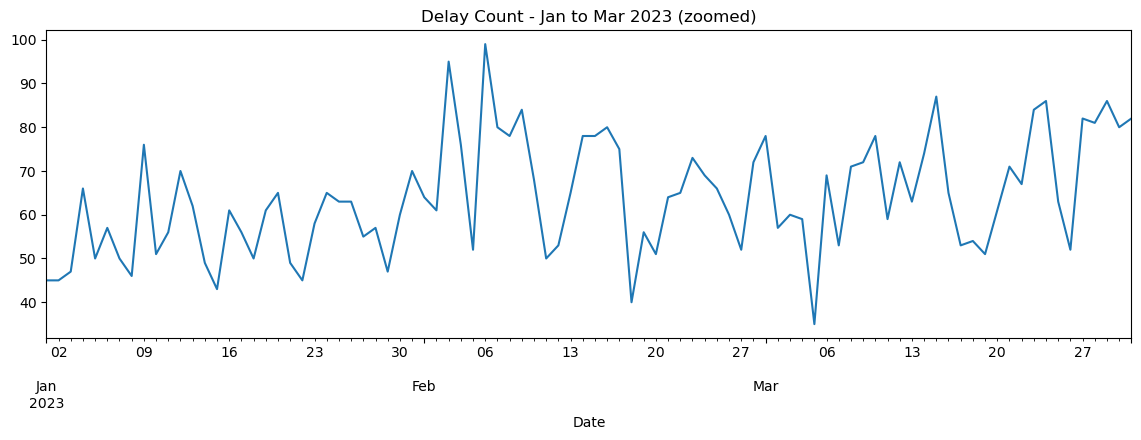

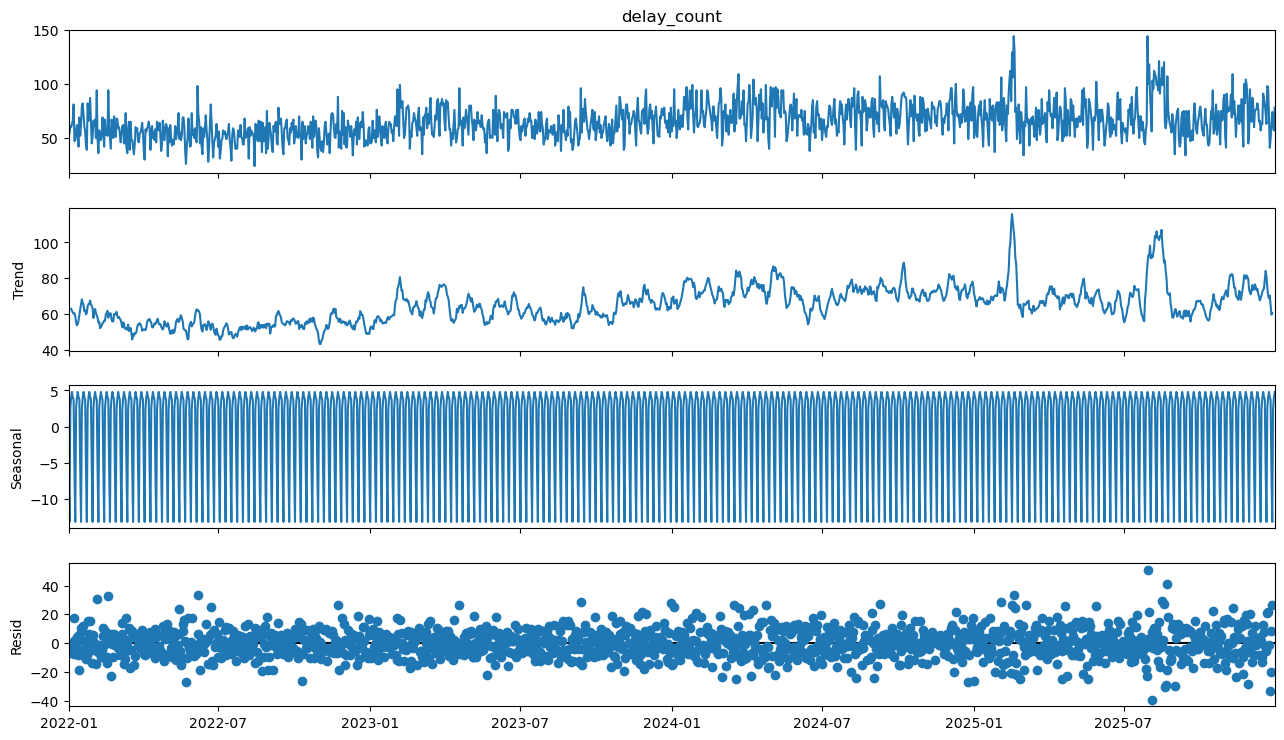

ADF Statistic: -3.8605
p-value: 0.0023


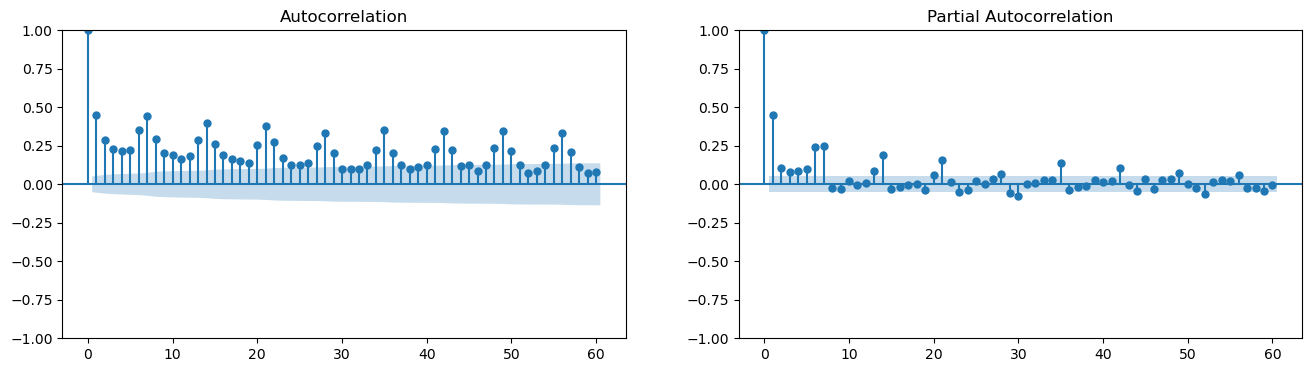

In [34]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Use delay_count as our target — cleaner series
series = daily_count.copy()

# 1. Zoom into ~3 months to check weekly pattern visually
series['2023-01':'2023-03'].plot(figsize=(14,4), title='Delay Count - Jan to Mar 2023 (zoomed)')
plt.show()

# 2. Seasonal decomposition (weekly assumption first: period=7)
decomp = seasonal_decompose(series, model='additive', period=7)
decomp.plot()
plt.gcf().set_size_inches(14, 8)
plt.show()

# 3. ADF test for stationarity
result = adfuller(series)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

# 4. ACF/PACF to look for spikes at lag 7 (weekly) and lag 365 (yearly, if data supports it)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series, lags=60, ax=axes[0])
plot_pacf(series, lags=60, ax=axes[1])
plt.show()

### Findings

Daily incident count is used as the forecasting target rather than total daily delay minutes, since the minutes series is distorted by the rare extreme-duration events identified earlier, while the incident count is a cleaner and more stable signal. A seasonal decomposition using an additive model with a 7-day period shows that the weekly seasonal swing stays roughly constant in size even as the underlying trend changes, supporting an additive rather than multiplicative seasonal structure. The Augmented Dickey-Fuller test rejects the null hypothesis of a unit root (p = 0.023), suggesting the series is stationary; however, since this test can miss slow-moving trends or level shifts, both differenced and non-differenced specifications are still compared using AIC and BIC rather than relying on the ADF result alone. The autocorrelation plot shows slow decay with repeating spikes every seven lags, confirming weekly seasonality, while the partial autocorrelation plot shows a sharp cutoff after lag 1 and lag 7, pointing toward autoregressive terms at both the daily and weekly level. Together, these diagnostics motivate a starting SARIMA specification of order (1,0,1) with seasonal order (1,0,1,7), to be refined through a systematic grid search.

### Train-Test Split

The series is split into a training set and a held-out test set consisting of the final 56 days, eight full weekly cycles, which is enough to properly evaluate the model's ability to capture weekly seasonality on unseen data.

In [35]:
# Hold out the last 8 weeks (56 days) as test set — enough to see 8 full weekly cycles
n_test = 56
train = daily_count.iloc[:-n_test]
test = daily_count.iloc[-n_test:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} days)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} days)")

Train: 2022-01-01 00:00:00 to 2025-11-05 00:00:00 (1405 days)
Test:  2025-11-06 00:00:00 to 2025-12-31 00:00:00 (56 days)


### Findings

The training set spans January 2022 through early November 2025 (1,405 days), and the test set covers the final 56 days of 2025. This split preserves chronological order, which is essential for time series evaluation, and ensures the model is tested on genuinely unseen future dates.

### Model Selection via Grid Search

A grid search is run over a range of non-seasonal and seasonal SARIMA orders, evaluating each candidate model by Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). Lower values indicate a better balance between model fit and complexity.

In [36]:
import itertools
import warnings
import pandas as pd
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# Parameter ranges to try — centered on what ACF/PACF suggested
p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1]
P_vals = [0, 1]
D_vals = [0, 1]
Q_vals = [0, 1]
S = 7

results = []

for p, d, q, P, D, Q in itertools.product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals):
    try:
        model = sm.tsa.statespace.SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, S),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        results.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, S),
            'AIC': fit.aic,
            'BIC': fit.bic
        })
    except Exception as e:
        continue

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print(results_df.head(10))

       order seasonal_order           AIC           BIC
0  (2, 0, 1)   (0, 1, 1, 7)  10776.881595  10803.063292
1  (2, 0, 1)   (1, 1, 1, 7)  10778.778091  10810.196127
2  (1, 0, 1)   (0, 1, 1, 7)  10780.651525  10801.596882
3  (2, 1, 1)   (0, 1, 1, 7)  10781.419243  10807.597339
4  (1, 0, 1)   (1, 1, 1, 7)  10782.623076  10808.804772
5  (2, 1, 1)   (1, 1, 1, 7)  10783.371980  10814.785695
6  (1, 1, 1)   (0, 1, 1, 7)  10788.139437  10809.081914
7  (1, 1, 1)   (1, 1, 1, 7)  10790.139679  10816.317775
8  (2, 0, 0)   (1, 1, 1, 7)  10809.274336  10835.456032
9  (0, 1, 1)   (0, 1, 1, 7)  10811.151538  10826.858395


### Findings

The best-fitting specification identified by the grid search is order (2,0,1) with seasonal order (0,1,1,7), though a simpler and very close alternative, order (1,0,1) with seasonal order (0,1,1,7), achieves nearly identical AIC and BIC values. Given the marginal difference in fit and the benefit of a more parsimonious model, order (1,0,1) with seasonal order (0,1,1,7) is selected as the final specification.

### Final Model, Diagnostics, and Forecast Evaluation

The selected SARIMA(1,0,1)(0,1,1,7) model is fit on the training data. Residual diagnostics are reviewed to confirm the residuals behave like white noise, the model then forecasts the 56 held-out test days, and forecast accuracy is measured using root mean squared error (RMSE) and mean absolute percentage error (MAPE).

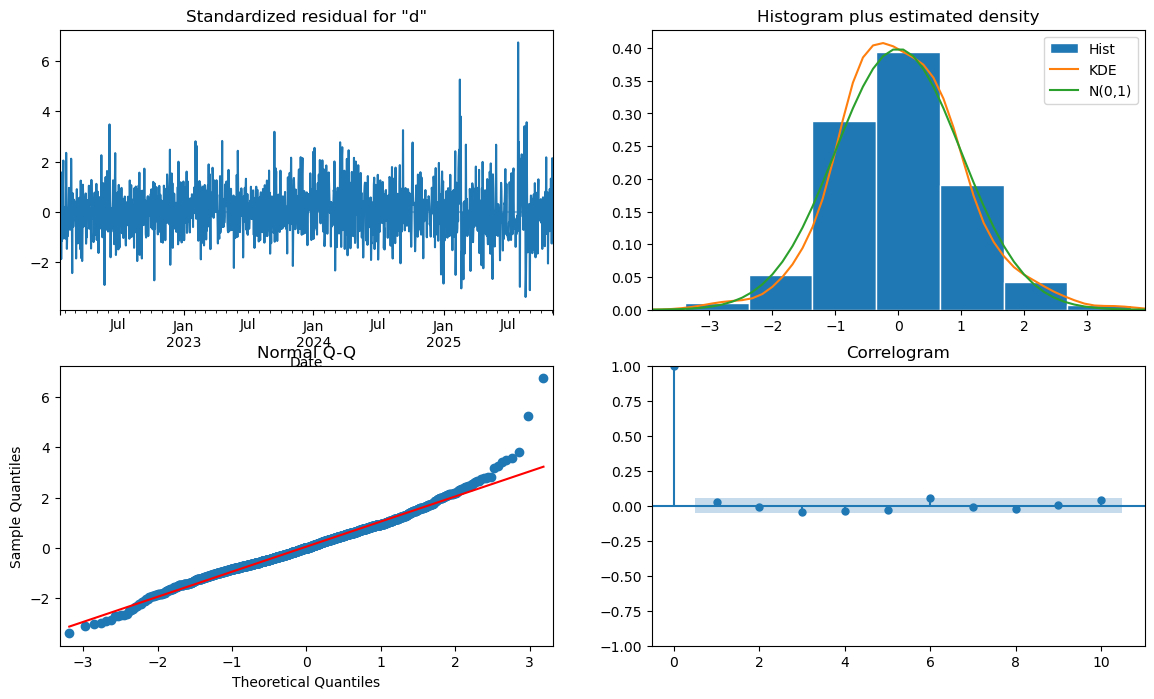

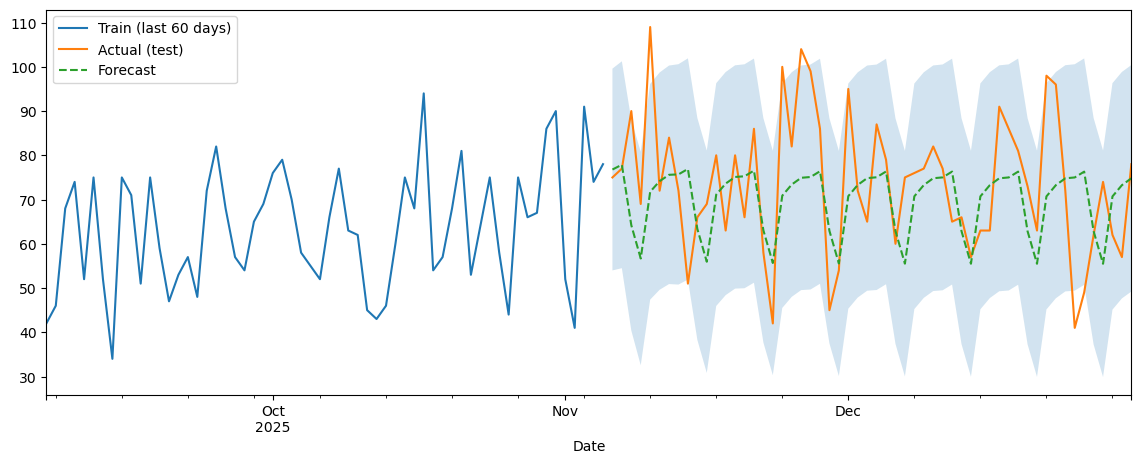

RMSE: 14.98
MAPE: 16.40%


In [37]:
best_order = (1, 0, 1)
best_seasonal_order = (0, 1, 1, 7)

final_model = sm.tsa.statespace.SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

# 1. Diagnostics — check residuals behave like white noise
final_fit.plot_diagnostics(figsize=(14, 8))
plt.show()

# 2. Forecast the held-out 56 days
forecast = final_fit.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 3. Plot forecast vs actual
fig, ax = plt.subplots(figsize=(14, 5))
train[-60:].plot(ax=ax, label='Train (last 60 days)')
test.plot(ax=ax, label='Actual (test)')
forecast_mean.plot(ax=ax, label='Forecast', style='--')
ax.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
ax.legend()
plt.show()

# 4. Accuracy metrics
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = mean_absolute_percentage_error(test, forecast_mean)

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

### Findings

On the 56-day held-out test period, the model achieves a root mean squared error of 14.98 incidents per day and a mean absolute percentage error of 16.40 percent. Relative to average daily incident volumes implied by the yearly record counts, this represents a reasonably useful forecast for operational planning purposes, though it is not precise enough to schedule staffing at a granular level without an added margin of safety. The forecast plot shows the model successfully tracking the weekly seasonal pattern, with most forecast error concentrated around occasional spikes that fall outside the typical weekly cycle, consistent with the outlier-driven behavior observed throughout this analysis.

## 12. Conclusions

This analysis addressed two business questions about TTC subway delays. On the question of what drives delays, the Pareto analysis shows that delay time is concentrated in a moderate number of causes, with passenger and security related incidents, specifically disorderly patrons, unauthorized track access, and other passenger issues, together accounting for close to a quarter of all lost service minutes. This suggests that station security and passenger management initiatives could meaningfully reduce total delay time, potentially more so than equipment-focused investments alone. The Random Forest classifier further shows that situational factors such as line, time of day, and day of week have only limited power to predict whether an individual record will be a delay, correctly classifying about 63 percent of held-out records. This indicates that schedule-based features are not sufficient on their own, and that incorporating external data such as weather conditions or real-time operational status would likely be necessary to build a substantially more accurate classifier.

On the question of predicting delay volume, the SARIMA model demonstrates that daily delay incident counts follow a clear and learnable weekly seasonal pattern, and the final model forecasts 56 days out-of-sample with a mean absolute percentage error of roughly 16 percent. This level of accuracy is sufficient to support medium-term operational planning, such as anticipating weekly demand cycles for maintenance scheduling or customer communication, though it is less suited to predicting isolated severe incidents, which by nature are driven by unpredictable events rather than seasonal patterns.

Overall, the two models are complementary: the classification approach identifies which operational categories are most associated with delays at the individual record level, while the time series approach forecasts aggregate delay volume at the daily level. Together they support a two-pronged operational response: targeting the specific passenger-related causes that drive the largest share of lost time, while using the volume forecast to plan staffing and communication around expected weekly demand patterns. The most promising direction for future work is enriching the dataset with weather and real-time operational variables, which would likely improve both classification accuracy and the precision of the delay volume forecast.